In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [3]:
from knn import UserKNN

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Load processed splits
train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/validation.csv")
test = pd.read_csv("../data/processed/test.csv")

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

Train: (80000, 4)
Validation: (10000, 4)
Test: (10000, 4)


In [5]:
from knn import UserKNN
import inspect

print(inspect.getsource(UserKNN))

class UserKNN:
    def __init__(self, k=20):
        self.k = k
        self.user_item_matrix = None
        self.user_similarity = None
        self.user_ids = None
        self.user_means = None
        self.global_mean = None

    def fit(self, train_df):
        # Global fallback
        self.global_mean = train_df["rating"].mean()

        # User-item matrix
        self.user_item_matrix = train_df.pivot_table(
            index="user_id",
            columns="item_id",
            values="rating"
        )

        # Compute user means
        self.user_means = self.user_item_matrix.mean(axis=1)

        # Mean-center ratings
        matrix_centered = self.user_item_matrix.sub(self.user_means, axis=0)

        # Fill missing values with 0 for similarity
        matrix_filled = matrix_centered.fillna(0)

        # Compute cosine similarity
        self.user_similarity = cosine_similarity(matrix_filled)

        # Store user ids
        self.user_ids = self.user_item_matrix.index.t

In [6]:
# Train UserKNN
knn_model = UserKNN(k=20)
knn_model.fit(train)

# Predict on validation
val_predictions_knn = knn_model.predict(val)

rmse_knn = np.sqrt(mean_squared_error(val["rating"], val_predictions_knn))

print("Validation RMSE (UserKNN):", round(rmse_knn, 4))

Validation RMSE (UserKNN): 0.9417


In [7]:
# Hyperparameter tuning for k

for k in [5, 10, 20, 40, 60]:
    model = UserKNN(k=k)
    model.fit(train)
    preds = model.predict(val)
    rmse = np.sqrt(mean_squared_error(val["rating"], preds))
    print(f"k={k}, Validation RMSE={round(rmse,4)}")

k=5, Validation RMSE=0.9833
k=10, Validation RMSE=0.9546
k=20, Validation RMSE=0.9417
k=40, Validation RMSE=0.9416
k=60, Validation RMSE=0.9429


In [8]:
best_k = 20  # Replace with your best value

best_model = UserKNN(k=best_k)
best_model.fit(train)

test_preds = best_model.predict(test)
test_rmse = np.sqrt(mean_squared_error(test["rating"], test_preds))

print("Test RMSE (UserKNN):", round(test_rmse,4))

Test RMSE (UserKNN): 0.9422


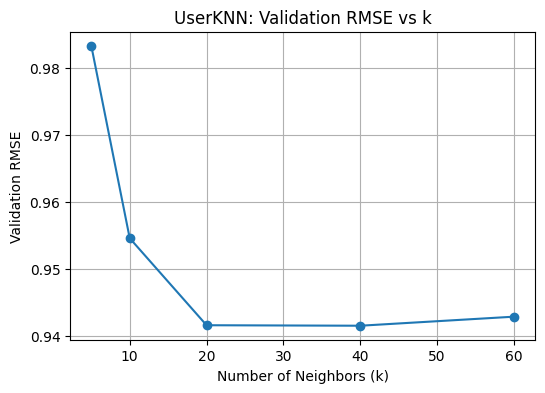

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt

k_values = [5, 10, 20, 40, 60]
rmse_values = []

for k in k_values:
    model = UserKNN(k=k)
    model.fit(train)
    preds = model.predict(val)
    rmse = np.sqrt(mean_squared_error(val["rating"], preds))
    rmse_values.append(rmse)

plt.figure(figsize=(6,4))
plt.plot(k_values, rmse_values, marker='o')
plt.title("UserKNN: Validation RMSE vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation RMSE")
plt.grid(True)
plt.show()

plt.savefig("../results/figures/userknn_k_tuning.png")
plt.show()

In [10]:
from knn import ItemKNN

In [16]:
item_model = ItemKNN(k=10)
item_model.fit(train)

val_preds_item = item_model.predict(val)
rmse_item = np.sqrt(mean_squared_error(val["rating"], val_preds_item))

print("Validation RMSE (ItemKNN):", round(rmse_item,4))

Validation RMSE (ItemKNN): 0.971


In [17]:
test_preds_item = item_model.predict(test)
test_rmse_item = np.sqrt(mean_squared_error(test["rating"], test_preds_item))

print("Test RMSE (ItemKNN):", round(test_rmse_item,4))

Test RMSE (ItemKNN): 0.9705


k=5, RMSE=0.9938
k=10, RMSE=0.9710
k=20, RMSE=0.9711
k=40, RMSE=0.9816
k=60, RMSE=0.9903


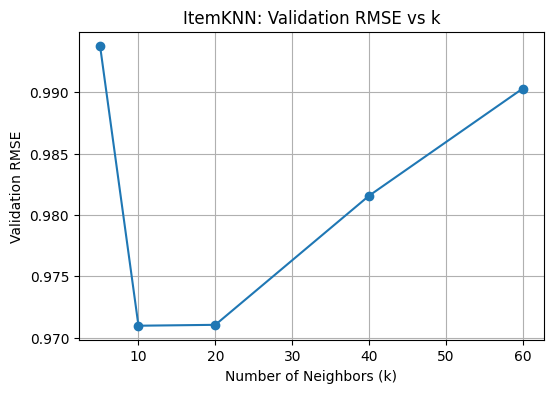

In [18]:
import matplotlib.pyplot as plt

k_values = [5, 10, 20, 40, 60]
rmse_values_item = []

for k in k_values:
    model = ItemKNN(k=k)
    model.fit(train)
    
    preds = model.predict(val)
    rmse = np.sqrt(mean_squared_error(val["rating"], preds))
    
    rmse_values_item.append(rmse)
    print(f"k={k}, RMSE={rmse:.4f}")

# Plot
plt.figure(figsize=(6,4))
plt.plot(k_values, rmse_values_item, marker='o')
plt.title("ItemKNN: Validation RMSE vs k")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation RMSE")
plt.grid(True)

plt.savefig("../results/figures/itemknn_k_tuning.png")
plt.show()